In [45]:
# NeuroGym W&B — LN vs noLN per architecture
from __future__ import annotations

import warnings
from statistics import mean, stdev

import matplotlib.pyplot as plt
import wandb

In [46]:
ENTITY = "royeyono"
PROJECT = "ng-perceptualdecisionmaking-v0"
PATH = f"{ENTITY}/{PROJECT}"

ARCHS = ("vanilla", "lstm")
LABELS = {"vanilla": "Vanilla RNN", "lstm": "LSTM"}
LN_LABELS = {True: "LayerNorm", False: "No LayerNorm"}
LN_COLORS = {True: "#1f77b4", False: "#ff7f0e"}
TOP_K = 5
PLOT_METRIC = "eval/trial_accuracy"
RANK_METRIC = "eval/trial_accuracy_auc"

print(PATH, f"top {TOP_K} by AUC → mean ± std")

royeyono/ng-perceptualdecisionmaking-v0 top 5 by AUC → mean ± std


In [47]:
def parse_run_name(name: str) -> tuple[str | None, bool | None]:
    """Return (arch, layer_norm) from batch run name ng_*_{tag}_*."""
    if "_ei_" in name:
        return "ei", None
    if "_vanilla_ln_" in name:
        return "vanilla", True
    if "_vanilla_noln_" in name:
        return "vanilla", False
    if "_lstm_ln_" in name:
        return "lstm", True
    if "_lstm_noln_" in name:
        return "lstm", False
    return None, None


def run_meta(run: wandb.apis.public.Run) -> tuple[str | None, bool | None]:
    arch, ln = parse_run_name(run.name or "")
    if arch is not None:
        return arch, ln
    keys = list(run.config.keys())
    if not keys:
        return None, None
    return run.config.get("arch"), run.config.get("layer_norm")


def final_metric(run: wandb.apis.public.Run, key: str) -> float | None:
    v = run.summary.get(key)
    if v is not None:
        return float(v)
    last = None
    for row in run.history(keys=[key], pandas=False):
        if row.get(key) is not None:
            last = float(row[key])
    return last


def metric_series(run: wandb.apis.public.Run, key: str) -> list[tuple[int, float]]:
    pts = []
    for row in run.history(keys=[key, "_step"], pandas=False):
        if row.get(key) is not None:
            pts.append((int(row["_step"]), float(row[key])))
    pts.sort()
    return pts


def top_k_by_auc(runs: list[wandb.apis.public.Run], k: int) -> list[wandb.apis.public.Run]:
    scored = []
    for run in runs:
        score = final_metric(run, RANK_METRIC)
        if score is None:
            warnings.warn(f"skip {run.name}: no {RANK_METRIC}")
            continue
        scored.append((score, run))
    scored.sort(key=lambda x: (-x[0], x[1].id))
    return [run for _, run in scored[:k]]


def average_curve(runs: list[wandb.apis.public.Run], metric: str) -> tuple[list[int], list[float], list[float]]:
    """Per-step mean and std across runs."""
    by_step: dict[int, list[float]] = {}
    for run in runs:
        series = metric_series(run, metric)
        if not series:
            warnings.warn(f"skip {run.name}: no {metric}")
            continue
        for step, val in series:
            by_step.setdefault(step, []).append(val)
    steps = sorted(by_step)
    means, stds = [], []
    for step in steps:
        vals = by_step[step]
        means.append(mean(vals))
        stds.append(stdev(vals) if len(vals) > 1 else 0.0)
    return steps, means, stds

In [48]:
api = wandb.Api()
eligible = []
for r in api.runs(PATH):
    if r.state != "finished":
        continue
    arch, ln = run_meta(r)
    if arch in ARCHS and ln is not None:
        eligible.append(r)
if not eligible:
    raise ValueError(f"No eligible runs in {PATH!r}")

picked: dict[tuple[str, bool], list[wandb.apis.public.Run]] = {}
curves: dict[tuple[str, bool], tuple[list[int], list[float], list[float]]] = {}

for arch in ARCHS:
    for ln in (True, False):
        pool = [r for r in eligible if run_meta(r) == (arch, ln)]
        top = top_k_by_auc(pool, TOP_K)
        picked[(arch, ln)] = top
        curves[(arch, ln)] = average_curve(top, PLOT_METRIC)
        print(f"{LABELS[arch]} {LN_LABELS[ln]}: {len(top)}/{TOP_K} (pool {len(pool)})")

print(f"\n{'arch':<8} {'ln':<14} {'rank':<5} {'auc':>10}  run")
print("-" * 60)
for (arch, ln), group in picked.items():
    for rank, run in enumerate(group, 1):
        auc = final_metric(run, RANK_METRIC)
        print(f"{arch:<8} {LN_LABELS[ln]:<14} {rank:<5} {auc:>10.1f}  {run.name}")

Vanilla RNN LayerNorm: 5/5 (pool 10)
Vanilla RNN No LayerNorm: 5/5 (pool 10)
LSTM LayerNorm: 5/5 (pool 10)
LSTM No LayerNorm: 5/5 (pool 9)

arch     ln             rank         auc  run
------------------------------------------------------------
vanilla  LayerNorm      1         4244.8  ng_9647436_vanilla_ln_26
vanilla  LayerNorm      2         4238.2  ng_9647436_vanilla_ln_31
vanilla  LayerNorm      3         4237.1  ng_9647436_vanilla_ln_36
vanilla  LayerNorm      4         4172.2  ng_9647436_vanilla_ln_21
vanilla  LayerNorm      5         4128.4  ng_9647436_vanilla_ln_41
vanilla  No LayerNorm   1         4028.3  ng_9647436_vanilla_noln_47
vanilla  No LayerNorm   2         3902.2  ng_9647436_vanilla_noln_42
vanilla  No LayerNorm   3         3745.4  ng_9647436_vanilla_noln_37
vanilla  No LayerNorm   4         3446.7  ng_9647436_vanilla_noln_32
vanilla  No LayerNorm   5         2856.7  ng_9647436_vanilla_noln_27
lstm     LayerNorm      1         4254.1  ng_9647436_lstm_ln_43
lstm     

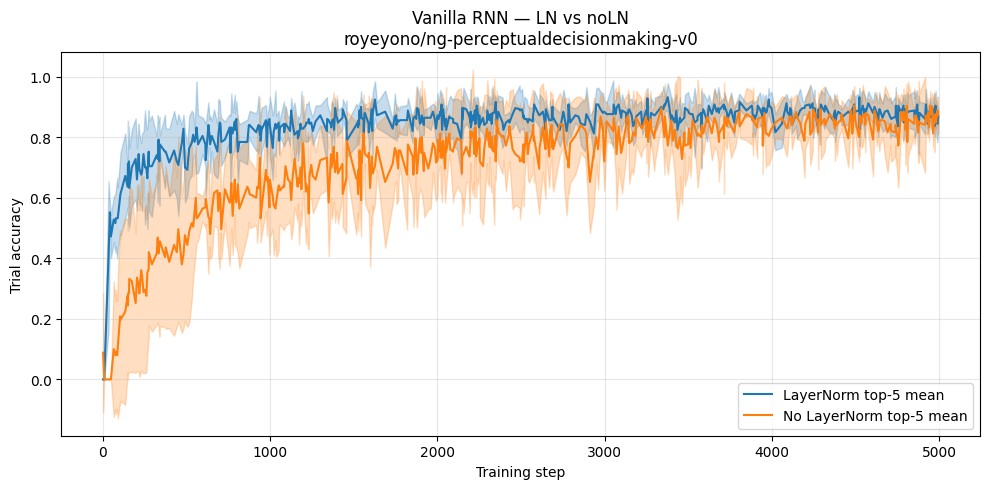

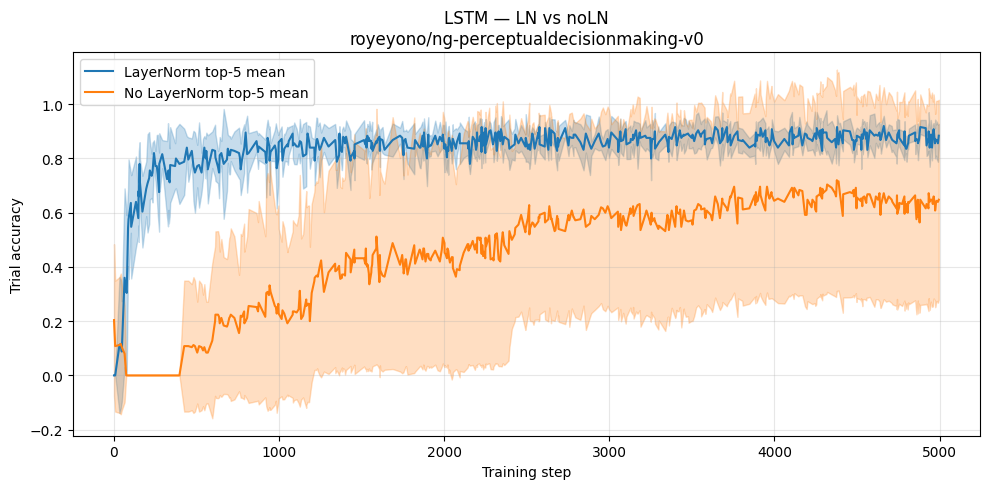

In [49]:
def plot_ln_comparison(arch: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    for ln in (True, False):
        steps, means, stds = curves[(arch, ln)]
        if not steps:
            warnings.warn(f"no curve: {arch} {LN_LABELS[ln]}")
            continue
        color = LN_COLORS[ln]
        n = len(picked[(arch, ln)])
        ax.plot(steps, means, color=color, label=f"{LN_LABELS[ln]} top-{n} mean")
        ax.fill_between(
            steps,
            [m - s for m, s in zip(means, stds)],
            [m + s for m, s in zip(means, stds)],
            color=color,
            alpha=0.25,
        )
    ax.set(xlabel="Training step", ylabel="Trial accuracy", title=f"{LABELS[arch]} — LN vs noLN\n{PATH}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_ln_comparison("vanilla")
plot_ln_comparison("lstm")

Selected EI runs: 5/5


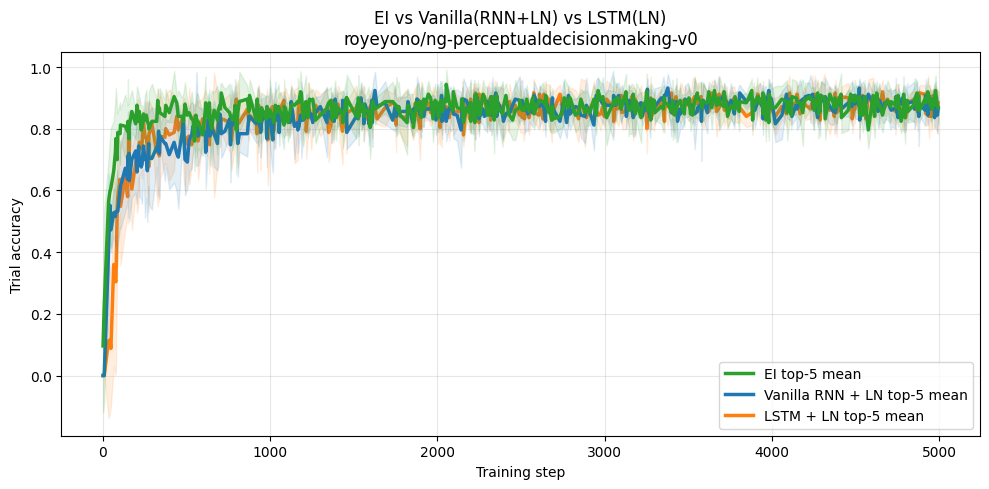


Top runs used (by AUC):

EI
  #1 auc=4383.8  ng_9647436_ei_25
  #2 auc=4349.2  ng_9647436_ei_30
  #3 auc=4336.3  ng_9647436_ei_40
  #4 auc=4271.2  ng_9647436_ei_45
  #5 auc=4257.1  ng_9647436_ei_35

Vanilla(RNN+LN)
  #1 auc=4244.8  ng_9647436_vanilla_ln_26
  #2 auc=4238.2  ng_9647436_vanilla_ln_31
  #3 auc=4237.1  ng_9647436_vanilla_ln_36
  #4 auc=4172.2  ng_9647436_vanilla_ln_21
  #5 auc=4128.4  ng_9647436_vanilla_ln_41

LSTM(LN)
  #1 auc=4254.1  ng_9647436_lstm_ln_43
  #2 auc=4253.2  ng_9647436_lstm_ln_38
  #3 auc=4187.9  ng_9647436_lstm_ln_33
  #4 auc=4157.3  ng_9647436_lstm_ln_28
  #5 auc=4116.0  ng_9647436_lstm_ln_48


In [50]:
# EI vs Vanilla(RNN+LN) vs LSTM(LN) — top TOP_K by AUC

def top_k_in_group(runs: list[wandb.apis.public.Run], arch: str, ln: bool | None) -> list[wandb.apis.public.Run]:
    pool = [r for r in runs if run_meta(r) == (arch, ln)]
    return top_k_by_auc(pool, TOP_K)


runs_all = [r for r in api.runs(PATH) if r.state == "finished"]

r_ei = top_k_in_group(runs_all, "ei", None)
r_vanilla_ln = top_k_in_group(runs_all, "vanilla", True)
r_lstm_ln = top_k_in_group(runs_all, "lstm", True)

print(f"Selected EI runs: {len(r_ei)}/{TOP_K}")

cur_ei = average_curve(r_ei, PLOT_METRIC)
cur_van = average_curve(r_vanilla_ln, PLOT_METRIC)
cur_lstm = average_curve(r_lstm_ln, PLOT_METRIC)

fig, ax = plt.subplots(figsize=(10, 5))

for label, color, z, picked_runs, (steps, means, stds) in (
    ("EI", "#2ca02c", 3, r_ei, cur_ei),
    ("Vanilla RNN + LN", "#1f77b4", 2, r_vanilla_ln, cur_van),
    ("LSTM + LN", "#ff7f0e", 1, r_lstm_ln, cur_lstm),
):
    if not steps:
        warnings.warn(f"no curve for {label}")
        continue
    n = len(picked_runs)
    ax.fill_between(
        steps,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color=color,
        alpha=0.12,
        zorder=z,
    )
    ax.plot(
        steps,
        means,
        color=color,
        linewidth=2.5,
        zorder=z + 0.1,
        label=f"{label} top-{n} mean",
    )

ax.set(
    xlabel="Training step",
    ylabel="Trial accuracy",
    title=f"EI vs Vanilla(RNN+LN) vs LSTM(LN)\n{PATH}",
)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("\nTop runs used (by AUC):")
for group_name, runs_group in (
    ("EI", r_ei),
    ("Vanilla(RNN+LN)", r_vanilla_ln),
    ("LSTM(LN)", r_lstm_ln),
):
    print(f"\n{group_name}")
    for i, r in enumerate(runs_group, 1):
        auc = final_metric(r, RANK_METRIC)
        print(f"  #{i} auc={auc:.1f}  {r.name}")